# Parameterisation of ice shelf basal melt rates in a proglacial lake

In this notebook we present a new melt parameterisation with coefficients fitted using our NEMO's outputs as reference. This parameterisation computes melt patterns from profiles of salinity and temperature before the front extrapolated under the shelf. We evaluate this parameterisation by comparing the obtained melt patterns with those of our NEMO simulations and those obtained using other parameterisations (Burgard et al. 2022; Hinck et al. 2022).

In [1]:
#import the libraries needed
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cmocean import cm as cmo
import numpy as np
import xarray as xr
from scipy.optimize import curve_fit

**name of the experiments and where to find them**

In [2]:
#define some names and paths to find the experiments
chemin="/ccc/work/cont003/gen6035/fiollaur/models/my_isomip/tests/" #path to where the NEMO's configuration is
config="config_article/" #NEMO's configuration
nom_fichierT="ISOMIP+_1m_grid_T.nc" #name of the file with outputs at T-point

In [3]:
#lists of the different restoring salinities and temperatures of the experiments
liste_salinite=["0_001","0_3","0_6","0_9"]
liste_temperature=["0_1","1","1-2","1-3","3","6","6-4","8","8-4","8-6","10","10-6","10-8"]

In [4]:
#reconstruct the name of the experiments
nom_experiences=[]
for sal in liste_salinite:
    for temp in liste_temperature:
        nom_exp="S"+sal+"_T"+temp
        nom_experiences.append(nom_exp)
        #print("exp_"+nom_exp+"/"+nom_fichierT)

In [5]:
#some checks
nbre_experiences=len(nom_experiences)
nbre_salin_diff=len(liste_salinite)
nbre_temp_diff=len(liste_temperature)
print(nbre_experiences)
print(nbre_salin_diff)
print(nbre_temp_diff)
print(nom_experiences)

52
4
13
['S0_001_T0_1', 'S0_001_T1', 'S0_001_T1-2', 'S0_001_T1-3', 'S0_001_T3', 'S0_001_T6', 'S0_001_T6-4', 'S0_001_T8', 'S0_001_T8-4', 'S0_001_T8-6', 'S0_001_T10', 'S0_001_T10-6', 'S0_001_T10-8', 'S0_3_T0_1', 'S0_3_T1', 'S0_3_T1-2', 'S0_3_T1-3', 'S0_3_T3', 'S0_3_T6', 'S0_3_T6-4', 'S0_3_T8', 'S0_3_T8-4', 'S0_3_T8-6', 'S0_3_T10', 'S0_3_T10-6', 'S0_3_T10-8', 'S0_6_T0_1', 'S0_6_T1', 'S0_6_T1-2', 'S0_6_T1-3', 'S0_6_T3', 'S0_6_T6', 'S0_6_T6-4', 'S0_6_T8', 'S0_6_T8-4', 'S0_6_T8-6', 'S0_6_T10', 'S0_6_T10-6', 'S0_6_T10-8', 'S0_9_T0_1', 'S0_9_T1', 'S0_9_T1-2', 'S0_9_T1-3', 'S0_9_T3', 'S0_9_T6', 'S0_9_T6-4', 'S0_9_T8', 'S0_9_T8-4', 'S0_9_T8-6', 'S0_9_T10', 'S0_9_T10-6', 'S0_9_T10-8']


In [6]:
#loading the domain
data_domain=xr.open_dataset(chemin+config+"SETTE/domain_f58N_pen01_smo4_h2km_z20m.nc")

**useful variables**

In [7]:
#variables associated to the equation of state
rhofw=1000.0 ; rho0=1000.38 ; S0=0.5 ; T0=4.0 #density of fresh water, reference density, reference salinity, reference temperature
print(rhofw,rho0,S0,T0)
coefs=[-2.274e-03,8.0228e-01,-6.121,1.3726e-02,3.3176e-03,-1.279e-02,1.135e-05] #coefficients of the simplified equation of state
print(coefs[0],coefs[1],coefs[2],coefs[3],coefs[4],coefs[5],coefs[6])
beta_lin=coefs[1]/rho0 #coefficient used in the parameterisation from Burgard et al. 2022 (salt contraction coefficient linear equation of state)
print(beta_lin)
    #coefficients used in our parameterisation
a0=coefs[0]
mu1=coefs[5]
lambda1=coefs[2]
print(a0,mu1,lambda1)

1000.0 1000.38 0.5 4.0
-0.002274 0.80228 -6.121 0.013726 0.0033176 -0.01279 1.135e-05
0.000801975249405226
-0.002274 -0.01279 -6.121


In [8]:
#time variables
conv_invs_invan=365.*24.*3600. #conversion coef
nbre_j_an=365 #number of days within a year
nbre_mois_an=12 #number of months within a year
fq_output=1 #output frequency in months
nbre_annee_total=15 #total number of simulated year
annee_deb_voulue=12 #first year to consider in the analyses
nbre_annee_voulue=4 #number of years to consider in the analyses
debmoy_yr=int((annee_deb_voulue-1)*(nbre_mois_an/fq_output)) #first time index to consider in the analyses
finmoy_yr=int(debmoy_yr+nbre_annee_voulue*nbre_mois_an/fq_output-1) #last time index to consider in the analyses
print(debmoy_yr,finmoy_yr)
size_time=int(nbre_annee_total*nbre_mois_an/fq_output) #size of time in the outputs
print(size_time)
print("number of time step considered: ",finmoy_yr-debmoy_yr+1)

132 179
180
number of time step considered:  48


In [9]:
#variables linked to spatial dimensions of the domain
size_z=data_domain.sizes['nav_lev']
size_x=data_domain.sizes['x']
size_y=data_domain.sizes['y']
print("z",size_z,"x",size_x,"y",size_y)

z 37 x 242 y 42


In [10]:
#coef param Clara Burgard
K=5.7e-5
print(K)

5.7e-05


In [11]:
#some other variables
L= 0.334e6 #latent heat of fusion of ice (J/kg)
cp= 4204.5837 #isobaric specific heat capacity of water (J/(kg*K))
g=9.80665 #gravity parameter (m/s2)
print(L,cp,g)
    #coefficients of the linear freezing temperature
l1=-0.0572;l2=0.0197;l3=-7.5519e-04
print(l1,l2,l3)

334000.0 4204.5837 9.80665
-0.0572 0.0197 -0.00075519


**mask used**

In [12]:
#ice-shelf mask from "top_level" and "rpi" variables of the domain file

shelf=(data_domain.rpi[0,:,:].where(data_domain.rpi[0,:,:]>0)).where(data_domain.top_level[0,:,:]>0) #ice field (rpi>0) + at least one cell with water (top_level>0)
shelf_norm=shelf/shelf #mask with only NaN and ones
shelf_norm0=shelf_norm.fillna(0) #mask with only zeros and ones

In [13]:
#some x-positions useful for the analyses
field_xpos=np.ones((size_y,size_x))*np.nan
for ypos in data_domain.y.values:
    field_xpos[ypos,:]=data_domain.x.values
print(np.nanmax(field_xpos*shelf_norm,axis=1)) 
print(np.nanmin(field_xpos*shelf_norm,axis=1)) 

xpos_front=164 #position of the front
xpos_dvtfront=164+1 #position before the front
xpos_gl=68 #position of the deepest grounding line

[ nan 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.
 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.
 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164. 164.  nan]
[nan 96. 96. 95. 95. 94. 83. 75. 72. 71. 70. 70. 69. 69. 69. 68. 68. 68.
 68. 68. 68. 68. 68. 68. 68. 68. 68. 69. 69. 69. 70. 70. 71. 72. 75. 83.
 95. 95. 95. 95. 96. nan]


/tmp/ipykernel_3213775/465214030.py:5: RuntimeWarning: All-NaN axis encountered
  print(np.nanmax(field_xpos*shelf_norm,axis=1))
/tmp/ipykernel_3213775/465214030.py:6: RuntimeWarning: All-NaN axis encountered
  print(np.nanmin(field_xpos*shelf_norm,axis=1))


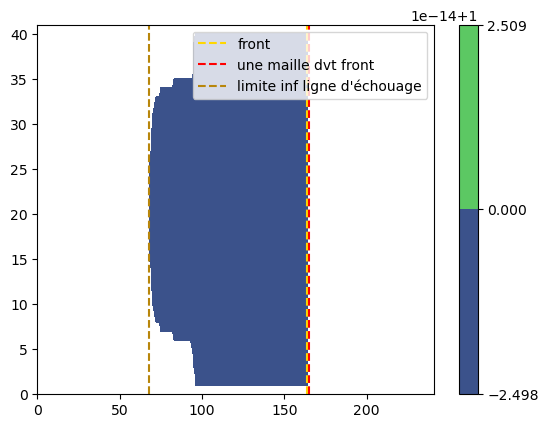

In [14]:
#some visualisation
plt.contourf(shelf_norm)
plt.plot(np.linspace(xpos_front,xpos_front,size_y),np.linspace(0,size_y-1,size_y), linestyle="--",color="gold",label="front")
plt.plot(np.linspace(xpos_dvtfront,xpos_dvtfront,size_y),np.linspace(0,size_y-1,size_y),linestyle="--",color="red",label="une maille dvt front")
plt.plot(np.linspace(xpos_gl,xpos_gl,size_y),np.linspace(0,size_y-1,size_y), linestyle="--",color="darkgoldenrod",label="limite inf ligne d'échouage")
plt.legend(loc="upper right")
plt.colorbar()
plt.show()

## compute the input maps of the parameterisation

**melt maps**

In [15]:
#melt rate in kg m−2 s−1 (mean over the last 4 years)
fonte_yrmoy=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    fonte_yrmoy.append((exp.sowflisf[debmoy_yr:finmoy_yr+1,:,:]*shelf_norm0).mean(axis=0)) #temporal mean
    exp.close()

In [16]:
print(len(fonte_yrmoy)==nbre_experiences)

True


**temperature and salinity maps**

In [17]:
#number of kilometers to consider to compute the mean profiles before the front
nbre_km=50
#vertical resolution in the open lake
delta_z=20.

In [18]:
#mean temperature and salinity over the last 4 years of simulation
T_yrmoy=[];S_yrmoy=[]
for l in range(nbre_experiences):
    #print(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    exp=xr.open_dataset(chemin+config+"exp_"+nom_experiences[l]+"/"+nom_fichierT)
    T_yrmoy.append(exp.votemper[debmoy_yr:finmoy_yr+1,:,:,:].mean(axis=0)) #temporal mean
    S_yrmoy.append(exp.vosaline[debmoy_yr:finmoy_yr+1,:,:,:].mean(axis=0)) #temporal mean
    exp.close()

In [19]:
print(len(T_yrmoy)==nbre_experiences)
print(len(S_yrmoy)==nbre_experiences)

True
True


In [20]:
#mean salinity and temperature profiles before the front (considering the first 50 km before the front)
#one profile per y-position, so T_yrmoy50km and S_yrmoy50km are 2D (z and y dimensions)
T_yrmoy50km=[];S_yrmoy50km=[]
for l in range(nbre_experiences):
    T_yrmoy50km.append(T_yrmoy[l][:,:,xpos_dvtfront:xpos_dvtfront+nbre_km//2+1].mean(axis=2)) #//2 because delta_x = 2 km
    S_yrmoy50km.append(S_yrmoy[l][:,:,xpos_dvtfront:xpos_dvtfront+nbre_km//2+1].mean(axis=2))

In [21]:
#Because of the penalisation, ice draft depth values could be different from the depth of the different vertical levels of NEMO. Here we save the indexes of NEMO's levels that flank the depth of the ice draft. 
#inf_map contains the index of the lower bound, and sup_map contains the index of the upper bound.

inf_map=((data_domain.isf_draft[0,:,:]-delta_z/2)//delta_z)

sup_map=inf_map+1

inf_map=inf_map*shelf_norm0 ; sup_map=sup_map*shelf_norm0

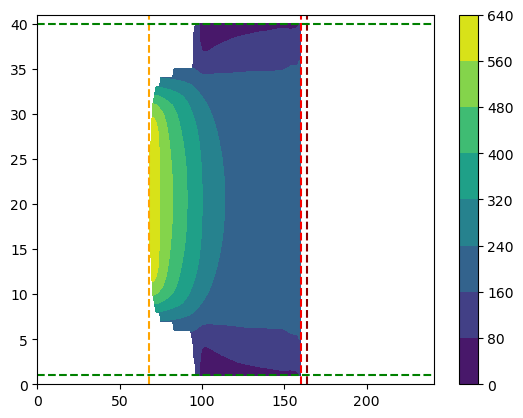

In [22]:
#some visualisation
plt.contourf(data_domain.isf_draft.where(data_domain.isf_draft>=20)[0,:,:])
plt.colorbar()
plt.plot(np.linspace(xpos_front,xpos_front,size_y),np.linspace(0,size_y-1,size_y),color="darkred",ls="--")
plt.plot(np.linspace(160,160,size_y),np.linspace(0,size_y-1,size_y),color="red",ls="--")
plt.plot(np.linspace(xpos_gl,xpos_gl,size_y),np.linspace(0,size_y-1,size_y),color="orange",ls="--")
plt.plot(np.linspace(0,size_x-1,size_x),np.linspace(1,1,size_x),color="green",ls="--")
plt.plot(np.linspace(0,size_x-1,size_x),np.linspace(40,40,size_x),color="green",ls="--")
plt.show()

In [23]:
#extrapolate under the shelf temperature and salinity values before the front 
#extrapolate everywhere the ice draft is at least 20 m (delta_z)
T_maps=[];S_maps=[]

for l in range(nbre_experiences):
    #compute some difference to weight the extrapolation
    ecart_inf=np.abs(data_domain.isf_draft[0,:,:]-T_yrmoy50km[l].deptht[inf_map.fillna(0).astype(int)])
    ecart_sup=np.abs(data_domain.isf_draft[0,:,:]-T_yrmoy50km[l].deptht[sup_map.fillna(0).astype(int)])

    #extrapolate
    T_maps_temp=((delta_z-ecart_inf)*T_yrmoy50km[l][inf_map.fillna(0).astype(int),:]+(delta_z-ecart_sup)*T_yrmoy50km[l][sup_map.fillna(0).astype(int),:])/delta_z
    S_maps_temp=((delta_z-ecart_inf)*S_yrmoy50km[l][inf_map.fillna(0).astype(int),:]+(delta_z-ecart_sup)*S_yrmoy50km[l][sup_map.fillna(0).astype(int),:])/delta_z
    
    #only where the ice draft is at least 20 m
    T_maps.append(T_maps_temp.where(data_domain.isf_draft[0,:,:]>=delta_z))#ice draft >=20m
    S_maps.append(S_maps_temp.where(data_domain.isf_draft[0,:,:]>=delta_z))#ice draft >=20m

**Coriolis**

In [24]:
#Coriolis coefficient
print(np.mean(data_domain.ff_t).values)
print(np.max(data_domain.ff_t).values)
print(np.min(data_domain.ff_t).values)
print(np.mean(data_domain.ff_f).values)
print(np.max(data_domain.ff_f).values)
print(np.min(data_domain.ff_f).values)
f=0.00012368

0.00012368130181503618
0.00012368130181503623
0.00012368130181503623
0.00012368130181503618
0.00012368130181503623
0.00012368130181503623


**Cavity slope**

The sine of the clope of the cavity could be computed from the formula: H/(h**2 + H**2)**(1/2) 

with 

H = maximal depth of the grounding line minus the depth of the ice draft of the front (m) 

h = distance along the x-axis between the position of the deepest part of the grounding line and the front (m)

We do not consider the penalised part to define the front

In [25]:
#distance along the x-axis between the position of the deepest grounding line and the front

##front position without penalisation
xpos_frontsp=1 #sp=without penalisation
while (True in (data_domain.rpi[0,1:-1,xpos_frontsp]==0.99))==True:
    xpos_frontsp+=1
xpos_frontsp-=1
print(xpos_frontsp)

#compute the distance in m
h=(xpos_frontsp-xpos_gl)*2*10**3 #xpos_gl = x-position of the deepest part of the groundling line ; delta_x= 2 km = 2 * 10**3 m
print(h)

160
184000


In [26]:
#mean depth of the ice draft of the front
print(data_domain.isf_draft[0,1:-1,xpos_frontsp].values)
Hsup=data_domain.isf_draft[0,1:-1,xpos_frontsp].mean(axis=0).values
print(Hsup)

[ 66.830345  87.66717  113.64321  124.976456 154.00763  155.84796
 163.81398  164.34383  171.45197  171.6844   175.9868   176.06375
 178.68994  178.73398  180.8466   180.66905  181.83391  181.84547
 182.39088  182.39667  182.37656  182.37001  181.76749  181.757
 180.5607   180.53874  178.55762  178.51726  175.90782  175.81711
 171.18849  170.97153  164.30763  163.81436  155.21948  153.25197
 124.81739  113.55021   87.594246  66.829346]
158.58598


In [27]:
#maximal depth of the grounding line => we want depth at W-point
#depth at W-point = depth at T-point + delta_z/2 
pos_Hinf=(data_domain.bottom_level[0,:,xpos_gl]-1).max(axis=0).values
Hinf=T_yrmoy50km[0].deptht[pos_Hinf].values+delta_z/2
print(Hinf)

640.0


In [28]:
#compute H
H=Hinf-Hsup
print(H)

481.4140167236328


In [29]:
#compute the sine of the slope
print(H,h)
print(H/(h**2 + H**2)**(0.5))
sin_pente_cav=0.0026164

481.4140167236328 184000
0.0026163715705707115


**mask of interest**

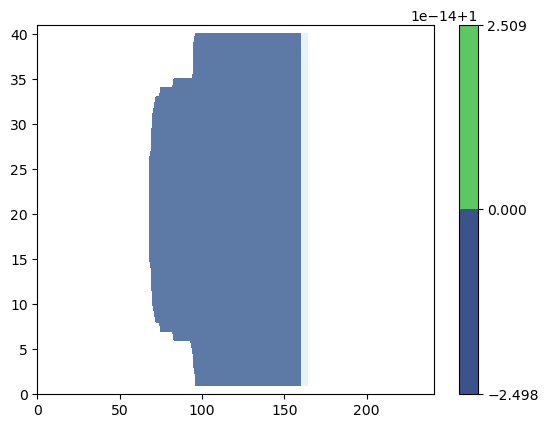

In [30]:
#same as shelf_norm mask but only considering where depth of the ice draft >= delta_z >= 20 m
masque_interet=(data_domain.isf_draft.where(data_domain.isf_draft>=delta_z)/data_domain.isf_draft)[0,:,:]

plt.contourf(masque_interet)
plt.colorbar()
plt.contourf(shelf_norm,colors="lightblue",alpha=0.3)
plt.show()

## fit of the coefficient of the new parameterisation

**define xdata and ydata for the fit**

In [31]:
#create lists that will be used to create xdata and ydata

listeT=[];listeS=[];listez=[];listemelt=[]

for l in range(nbre_experiences):
    for iy in range(1,size_y-1):
        for ix in range(1,size_x-1):
            if np.isnan(masque_interet[iy,ix])==False:
                listemelt.append(fonte_yrmoy[l][iy,ix]) #melt
                listeT.append(T_maps[l][iy,ix]) #temperature
                listeS.append(S_maps[l][iy,ix]) #salinity
                listez.append(data_domain.isf_draft[0,iy,ix]) #depth

In [32]:
#create xdata

xdata=np.ones((3,len(listemelt)))*np.nan
xdata[0,:]=listeS
xdata[1,:]=listeT
xdata[2,:]=listez

In [33]:
#create ydata
ydata=np.array(listemelt)

**define the function of the fit**

In [34]:
#new parameterisation, formula inspired by that of Clara Burgard (fit version)

def melt_revisiteCB(xdata,K,epsilonT):
    """
    Calculate the melt using the new parameterisation

    Parameters
    ----------
    xdata : vectors containing the salinity, temperature and depth values
        xdata[0,:] = Absolute Salinity (g/kg)
        xdata[1,:] = Conservative Temperature (°C)
        xdata[2,:] = depth of the ice draft (m)
    K,epsilonT : coefficients

    Returns
    -------
    melt : melt rate (kg m-2 s-1)
    """  
    global l1, l2, l3, L, cp, rho0, g, f, a0, mu1, lambda1, T0, sin_pente_cav 
    #coefficients of the linear freezing temperature (l1, l2, l3)
    #reference density, gravity coefficient, coriolis, coefficients of the equation of state (a0, mu1, lambda1)
    #reference temperature, sine of the cavity slope
    
    Tf=l1*xdata[0,:] + l2 + l3*g*rho0*(10**(-4))*xdata[2,:] #freezing temperature
    #print("Tf",Tf)
    P0=-a0*(mu1*xdata[2,:] + 0.5*lambda1*((epsilonT+1)*xdata[1,:]-2*T0)) 
    #print("P0",P0)
    melt=K*(cp/L)*np.abs(g*0.5/f*sin_pente_cav*P0*(xdata[1,:]-Tf))*(xdata[1,:]-Tf)
    return melt

**fitting**

In [35]:
fit_revisiteCB=curve_fit(melt_revisiteCB,xdata,ydata,full_output=True)
print(fit_revisiteCB[0])

[2.86541936e-04 1.77843420e+00]


In [36]:
#keep only 4 significant figures
coefs_revisiteCB=[2.865e-4,1.778]
#print(fit_revisiteCB[0],coefs_revisiteCB)

## Evaluate the new parameterisation and compare it to others (Burgard et al. 2022; Hinck et al., 2022)

**define some functions**

In [37]:
#Clara Burgard formula

def param_CB(S,T,z,K,l1, l2, l3, L, cp, rho0, g, f, beta_lin,sin_pente_cav):
    """
    Calculate the melt using Burgard et al. 2022 formula

    Parameters
    ----------

    S : Absolute Salinity (g/kg)
    T : Conservative Temperature (°C)
    z : depth of the ice draft (m)
    K : coefficient of the parameterisation
    l1, l2, l3 : coefficients of the linear freezing temperature
    L : latent heat of fusion of ice (J/kg)
    cp :  isobaric specific heat capacity of water (J/(kg*K))
    rho0 : reference density (kg/m3)
    g : gravity parameter (m/s2)
    f : Coriolis coefficient (s-1)
    beta_lin : salt contraction coefficient linear equation of state (1/(g/kg))
    sin_pente_cav : sine of the slope of the cavity

    Returns
    -------

    melt : melt rate (kg m-2 s-1)
    """  
    Tf=l1*S + l2 + l3*g*rho0*(10**(-4))*z #freezing temperature
    #print("Tf",Tf)
    P0=(cp/L)*beta_lin*S
    #print("P0",P0)
    melt=rho0*K*(cp/L)*g*0.5/np.abs(f)*sin_pente_cav*P0*np.abs(T-Tf)*(T-Tf)
    return melt

In [38]:
#new parameterisation, formula inspired by that of Clara Burgard (melt maps version)

def param_revisiteCB(S,T,z,K,epsilonT,l1, l2, l3, L, cp, rho0, g, f, a0, mu1, lambda1, T0, sin_pente_cav):
    """
    Calculate the melt using Burgard et al. 2022 formula

    Parameters
    ----------

    S : Absolute Salinity (g/kg)
    T : Conservative Temperature (°C)
    z : depth of the ice draft (m)
    K, epsilonT : coefficients of the parameterisation
    l1, l2, l3 : coefficients of the linear freezing temperature
    L : latent heat of fusion of ice (J/kg)
    cp :  isobaric specific heat capacity of water (J/(kg*K))
    rho0 : reference density (kg/m3)
    g : gravity parameter (m/s2)
    f : Coriolis coefficient (s-1)
    a0, mu1, lambda1 : coefficients of the equation of state
    T0 : reference temperature (°C)
    sin_pente_cav : sine of the slope of the cavity

    Returns
    -------

    melt : melt rate (kg m-2 s-1)
    """
    Tf=l1*S + l2 + l3*g*rho0*(10**(-4))*z #freezing temperature
    #print("Tf",Tf)
    P0=-a0*(mu1*z + 0.5*lambda1*((epsilonT+1)*T-2*T0))
    #print("P0",P0)
    melt=K*(cp/L)*np.abs(g*0.5/f*sin_pente_cav*P0*(T-Tf))*(T-Tf)
    return melt

**compute melt maps from the two parameterisations above**

In [39]:
#melt maps from the two parameterisations above
fonte_param_CB=[];fonte_param_revisiteCB=[]

for l in range(nbre_experiences):
    fonte_param_CB.append(param_CB(S_maps[l]*masque_interet,T_maps[l]*masque_interet,data_domain.isf_draft[0,:,:]*masque_interet,\
                                   K,l1, l2, l3, L, cp, rho0, g, f, beta_lin,sin_pente_cav))
    fonte_param_revisiteCB.append(param_revisiteCB(S_maps[l]*masque_interet,T_maps[l]*masque_interet,data_domain.isf_draft[0,:,:]*masque_interet,\
        coefs_revisiteCB[0],coefs_revisiteCB[1],l1, l2, l3, L, cp, rho0, g, f, a0, mu1, lambda1, T0, sin_pente_cav))

In [40]:
print(len(fonte_param_CB)==nbre_experiences)
print(len(fonte_param_revisiteCB)==nbre_experiences)

True
True


**define the different groups**

In [41]:
#manually define the groups (same as in the article)
Group0_manu=[];GroupI_manu=[];GroupII_manu=[];GroupIII_manu=[]

for l in range(nbre_experiences):
    if l%nbre_temp_diff==0:
        Group0_manu.append(l)
    elif (l%nbre_temp_diff in [1,2,3,4]) or (l%nbre_temp_diff==6 and l//nbre_temp_diff in [1,2,3]):
    #elif l%nbre_temp_diff in [1,2,3,4]:
        GroupI_manu.append(l)
    elif (l%nbre_temp_diff in [5,8]) or (l%nbre_temp_diff==6 and l//nbre_temp_diff in [0,1]) or (l%nbre_temp_diff==9 and l//nbre_temp_diff==3):
    #elif l%nbre_temp_diff in [5,6,8]:
        GroupII_manu.append(l)
    elif l%nbre_temp_diff in [7,9,10,11,12]:
        GroupIII_manu.append(l)
    else:
        print("il y a eu une erreur")

In [42]:
print("Group0 manu")
print(len(Group0_manu))
for id_group0 in Group0_manu:
    print(nom_experiences[id_group0])
    
print("//")
print("GroupI manu")
print(len(GroupI_manu))
for id_groupI in GroupI_manu:
    print(nom_experiences[id_groupI])
    
print("//")
print("GroupII manu")
print(len(GroupII_manu))
for id_groupII in GroupII_manu:
    print(nom_experiences[id_groupII])
    
print("//")
print("GroupIII manu")
print(len(GroupIII_manu))
for id_groupIII in GroupIII_manu:
    print(nom_experiences[id_groupIII])
    

Group0 manu
4
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
//
GroupI manu
19
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
//
GroupII manu
10
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
//
GroupIII manu
19
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


In [43]:
#mean per group
fonte_yrmoy_groups=[0,0,0,0] #reference (NEMO simulation)
fonte_param_CB_groups=[0,0,0,0] #Clara Burgard's formulation
fonte_param_revisiteCB_groups=[0,0,0,0] #new formulation


print("Group0")
for id_expG0 in Group0_manu:
    print(nom_experiences[id_expG0])
    fonte_yrmoy_groups[0]+=fonte_yrmoy[id_expG0]/len(Group0_manu)
    fonte_param_CB_groups[0]+=fonte_param_CB[id_expG0]/len(Group0_manu)
    fonte_param_revisiteCB_groups[0]+=fonte_param_revisiteCB[id_expG0]/len(Group0_manu)

print("GroupI")
for id_expGI in GroupI_manu:
    print(nom_experiences[id_expGI])
    fonte_yrmoy_groups[1]+=fonte_yrmoy[id_expGI]/len(GroupI_manu)
    fonte_param_CB_groups[1]+=fonte_param_CB[id_expGI]/len(GroupI_manu)
    fonte_param_revisiteCB_groups[1]+=fonte_param_revisiteCB[id_expGI]/len(GroupI_manu)
    
print("GroupII")
for id_expGII in GroupII_manu:
    print(nom_experiences[id_expGII])
    fonte_yrmoy_groups[2]+=fonte_yrmoy[id_expGII]/len(GroupII_manu)
    fonte_param_CB_groups[2]+=fonte_param_CB[id_expGII]/len(GroupII_manu)
    fonte_param_revisiteCB_groups[2]+=fonte_param_revisiteCB[id_expGII]/len(GroupII_manu)
    
    
print("GroupIII")
for id_expGIII in GroupIII_manu:
    print(nom_experiences[id_expGIII])
    fonte_yrmoy_groups[3]+=fonte_yrmoy[id_expGIII]/len(GroupIII_manu)
    fonte_param_CB_groups[3]+=fonte_param_CB[id_expGIII]/len(GroupIII_manu)
    fonte_param_revisiteCB_groups[3]+=fonte_param_revisiteCB[id_expGIII]/len(GroupIII_manu)


Group0
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
GroupI
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
GroupII
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
GroupIII
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


In [44]:
#mean input temperature and salinity maps per group

T_maps_groups=[0.0,0.0,0.0,0.0]
S_maps_groups=[0.0,0.0,0.0,0.0]

print("Group0")
for id_expG0 in Group0_manu:
    print(nom_experiences[id_expG0])
    T_maps_groups[0]+=T_maps[id_expG0]/len(Group0_manu)
    S_maps_groups[0]+=S_maps[id_expG0]/len(Group0_manu)

print("GroupI")
for id_expGI in GroupI_manu:
    print(nom_experiences[id_expGI])
    T_maps_groups[1]+=T_maps[id_expGI]/len(GroupI_manu)
    S_maps_groups[1]+=S_maps[id_expGI]/len(GroupI_manu)
    
print("GroupII")
for id_expGII in GroupII_manu:
    print(nom_experiences[id_expGII])
    T_maps_groups[2]+=T_maps[id_expGII]/len(GroupII_manu)
    S_maps_groups[2]+=S_maps[id_expGII]/len(GroupII_manu)

print("GroupIII")
for id_expGIII in GroupIII_manu:
    print(nom_experiences[id_expGIII])
    T_maps_groups[3]+=T_maps[id_expGIII]/len(GroupIII_manu)
    S_maps_groups[3]+=S_maps[id_expGIII]/len(GroupIII_manu)

Group0
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
GroupI
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
GroupII
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
GroupIII
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


In [45]:
#mean melt rates over the cavity per group
fonte_cavite_param_ref_groups=[] #reference (NEMO simulation)
fonte_cavite_param_CB_groups=[] #Clara Burgard's formulation
fonte_cavite_param_revisiteCB_groups=[] #new formulation

for lg in range(4):
    fonte_cavite_param_ref_groups.append((fonte_yrmoy_groups[lg]*masque_interet.fillna(0)).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
    fonte_cavite_param_CB_groups.append(fonte_param_CB_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
    fonte_cavite_param_revisiteCB_groups.append(fonte_param_revisiteCB_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))

In [46]:
#mean melt rates close to the grounding line and close to the front per group

    #close to the grounding line
fonte_GL_param_ref_groups=[] #reference (NEMO simulation)
fonte_GL_param_CB_groups=[] #Clara Burgard's formulation
fonte_GL_param_revisiteCB_groups=[] #new formulation
    #close to the front
fonte_front_param_ref_groups=[] #reference (NEMO simulation)
fonte_front_param_CB_groups=[] #Clara Burgard's formulation
fonte_front_param_revisiteCB_groups=[] #new formulation

for lg in range(4):
        #close to the grounding line
    fonte_GL_param_ref_groups.append((fonte_yrmoy_groups[lg]*masque_interet.fillna(0))[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
    fonte_GL_param_CB_groups.append(fonte_param_CB_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
    fonte_GL_param_revisiteCB_groups.append(fonte_param_revisiteCB_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
        #close to the front
    fonte_front_param_ref_groups.append((fonte_yrmoy_groups[lg]*masque_interet.fillna(0))[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))
    fonte_front_param_CB_groups.append(fonte_param_CB_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))
    fonte_front_param_revisiteCB_groups.append(fonte_param_revisiteCB_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))

In [47]:
#convert the mean melt rates over the cavity in m/yr

print("cavite ref",fonte_cavite_param_ref_groups)
print("cavite ref convertion",np.array([fonte_cavite_param_ref_groups])*conv_invs_invan/rhofw)
#print(str_fonte_cavite_param_ref_groups)
print("cavite CB",fonte_cavite_param_CB_groups)
print("cavite CB convertion",np.array([fonte_cavite_param_CB_groups])*conv_invs_invan/rhofw)
#print(str_fonte_cavite_param_CB_groups)
print("cavite revisiteCB",fonte_cavite_param_revisiteCB_groups)
print("cavite revisiteCB convertion",np.array([fonte_cavite_param_revisiteCB_groups])*conv_invs_invan/rhofw)
#print(str_fonte_cavite_param_revisiteCB_groups)

cavite ref [<xarray.DataArray ()>
array(2.32460098e-06)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.0001233)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.00053449)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.00309303)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0]
cavite ref convertion [[7.33086165e-02 3.88847294e+00 1.68557800e+01 9.75419173e+01]]
cavite CB [<xarray.DataArray ()>
array(1.6607718e-08, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(2.6063979e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(1.1290968e-05, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(2.305957

In [48]:
#convert the mean melt rates close to the grounding line and close to the front in m/yr
print("GL ref",fonte_GL_param_ref_groups)
print("GL ref convertion",np.array([fonte_GL_param_ref_groups])*conv_invs_invan/rhofw)
print("GL CB",fonte_GL_param_CB_groups)
print("GL CB convertion",np.array([fonte_GL_param_CB_groups])*conv_invs_invan/rhofw)
print("GL revisiteCB",fonte_GL_param_revisiteCB_groups)
print("GL revisiteCB convertion",np.array([fonte_GL_param_revisiteCB_groups])*conv_invs_invan/rhofw)
print("//")
print("front ref",fonte_front_param_ref_groups)
print("front ref convertion",np.array([fonte_front_param_ref_groups])*conv_invs_invan/rhofw)
print("front CB",fonte_front_param_CB_groups)
print("front CB convertion",np.array([fonte_front_param_CB_groups])*conv_invs_invan/rhofw)
print("front revisiteCB",fonte_front_param_revisiteCB_groups)
print("front revisiteCB convertion",np.array([fonte_front_param_revisiteCB_groups])*conv_invs_invan/rhofw)

GL ref [<xarray.DataArray ()>
array(1.08711408e-05)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.00021803)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.00040823)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0, <xarray.DataArray ()>
array(0.00085537)
Coordinates:
    nav_lev       float32 0.0
    time_counter  float64 0.0]
GL ref convertion [[ 0.3428323   6.87584722 12.87391305 26.97490806]]
GL CB [<xarray.DataArray ()>
array(5.3702188e-08, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(3.1788045e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(8.115242e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(1.6214084e-05, dtype=float32)
Co

**figure of the mean input temperature maps**

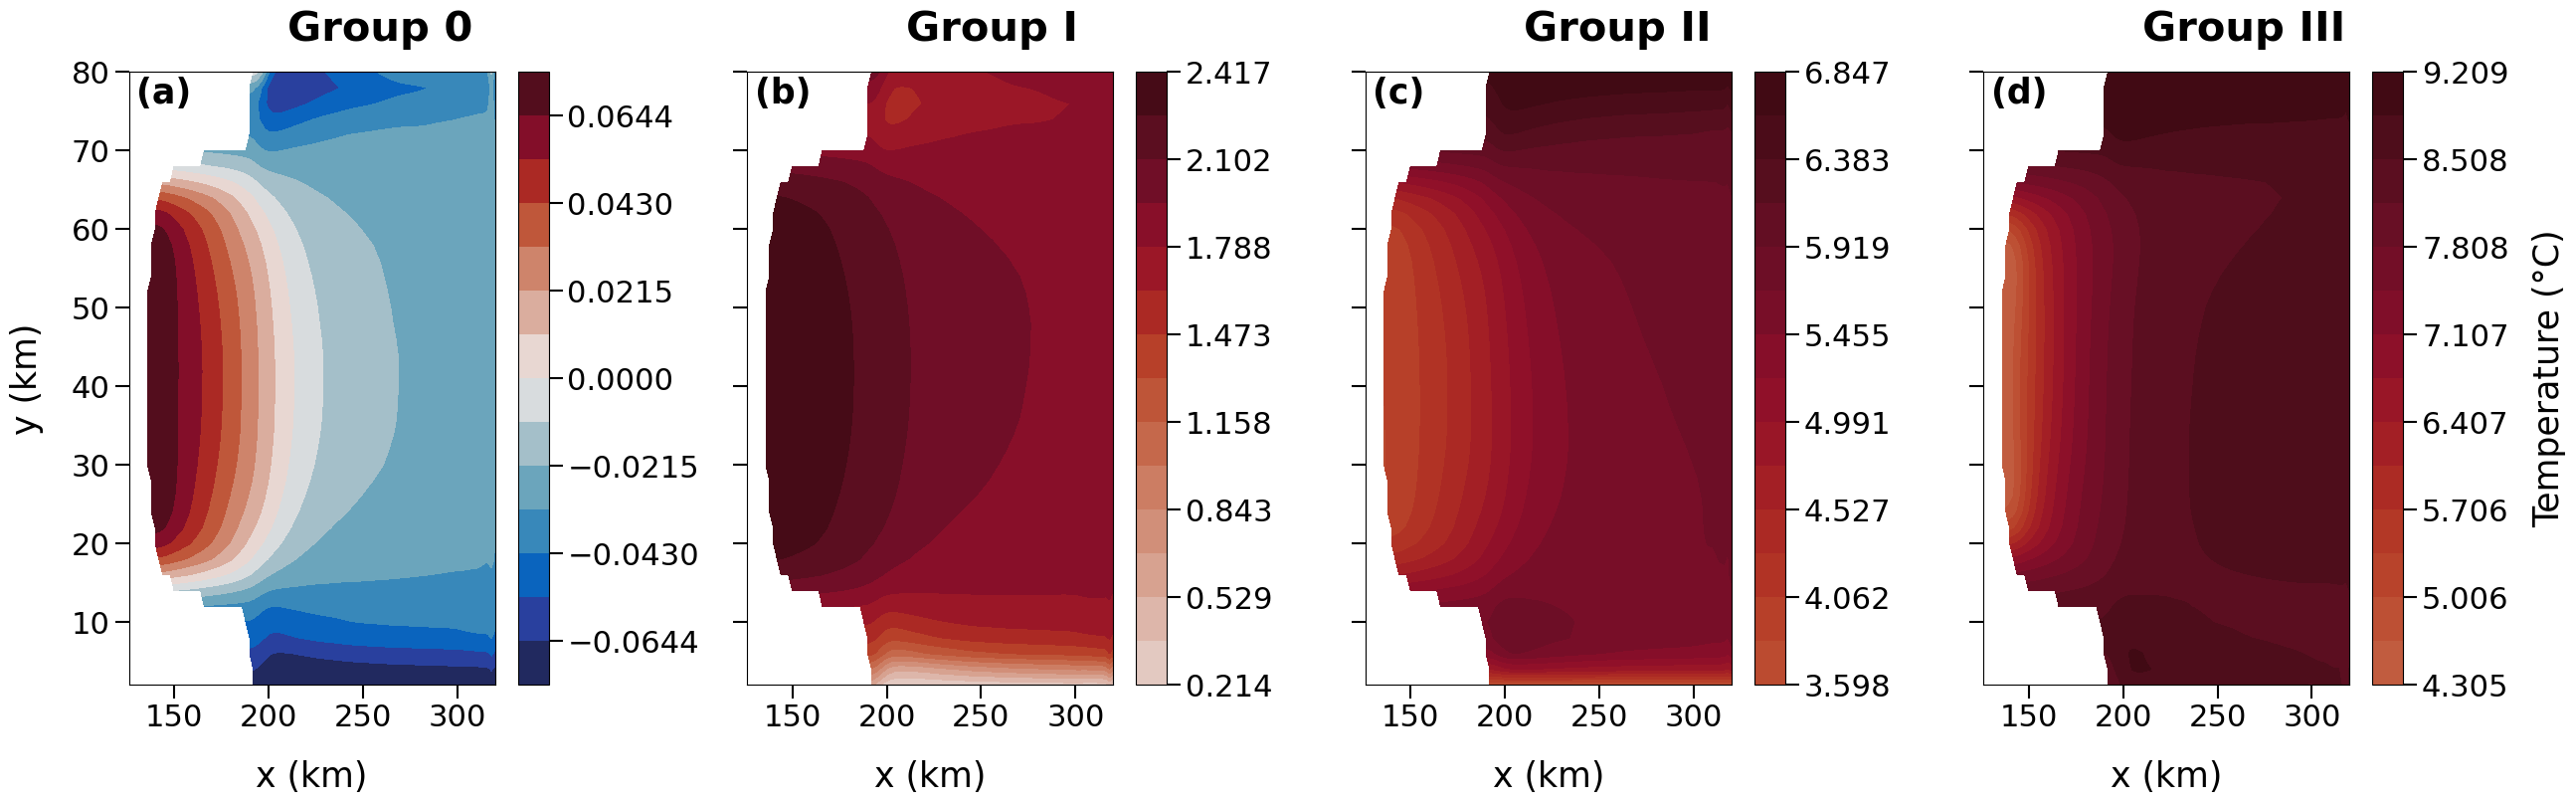

In [49]:
#figure of the mean input temperature maps per group
fig_input,(axi11,axi12,axi13,axi14)=plt.subplots(1,4,figsize=(30,8),sharex=True,sharey=True)
fig_input.subplots_adjust(wspace=0.35)

axesi=[(axi11,axi12,axi13,axi14)]

#some labels
labelsubfigi=[("(a)","(b)","(c)","(d)")]

#iterate over the groups
for li in range(4):
    
    #temperature maps
    val_mini0=T_maps_groups[li].min(axis=(0,1)) ; val_maxi0=T_maps_groups[li].max(axis=(0,1))
    if li==0:
        cfi0=axesi[0][li].contourf(T_maps_groups[li].x[xpos_gl-5:xpos_frontsp+1]*2,T_maps_groups[li].y[1:-1]*2,(T_maps_groups[li]*masque_interet)[1:-1,xpos_gl-5:xpos_frontsp+1],levels=np.linspace(-np.max(np.abs([val_mini0,val_maxi0])),np.max(np.abs([val_mini0,val_maxi0])),15),cmap=cmo.balance,norm=mcolors.TwoSlopeNorm(vcenter=0))
    else:
        cfi0=axesi[0][li].contourf(T_maps_groups[li].x[xpos_gl-5:xpos_frontsp+1]*2,T_maps_groups[li].y[1:-1]*2,(T_maps_groups[li]*masque_interet)[1:-1,xpos_gl-5:xpos_frontsp+1],levels=np.linspace(val_mini0,val_maxi0,15),cmap=cmo.balance,norm=mcolors.TwoSlopeNorm(vcenter=0))
    #set up the colorbar
    cbari0=plt.colorbar(cfi0)
    cbari0.ax.tick_params(labelsize=22,size=10,width=1.5)
    
        #set up some labels
    axesi[0][li].text(130,76,labelsubfigi[0][li],fontsize=25,fontweight="bold")
    
        #set up the axes
    axesi[0][li].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    axesi[0][li].set_xlabel("x (km)",fontsize=25,labelpad=20)

#legend of the colorbar
cbari0.set_label(label="Temperature (°C)",size=25,labelpad=17)
   
#legend of the y-axis
axesi[0][0].set_ylabel("y (km)",fontsize=25,labelpad=20)

#name of the groupes
axesi[0][0].text(210,84,"Group 0",fontsize=30,fontweight="bold")
axesi[0][1].text(210,84,"Group I",fontsize=30,fontweight="bold")
axesi[0][2].text(210,84,"Group II",fontsize=30,fontweight="bold")
axesi[0][3].text(210,84,"Group III",fontsize=30,fontweight="bold")

plt.show()
#save the figure
#fig_input.savefig("Cartes_input_param.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

**linear param (Hinck et al. 2022)**

In [50]:
#define some useful variables for the linear param
Csw=0.01 ; Cfw=2.5e-4 #tuning coefficients respectively for ocean and lake
rho_sw=1028. #reference density (kg/m3)
cp_sw=3974. #specific heat capacity of seawater (J/(kg K))
Lhinck=3.35e5 #latent heat of fusion of ice (J/kg)
gamma=10**(-4) #thermal exchange velocity (m/s)

print(Csw,Cfw)
print(rho_sw,cp_sw)
print(Lhinck,gamma)

0.01 0.00025
1028.0 3974.0
335000.0 0.0001


In [51]:
#coeffcients of the freezing temperature of the linear param
l1BG=-0.057 ; l2BG=0.0939 ; l3BG=-7.64e-4
print(l1BG,l2BG,l3BG)

-0.057 0.0939 -0.000764


**calculs des taux de fonte et d'analyse**

In [52]:
#formulation of Hinck et al. 2022
def param_lin(S,T,z,C,l1BG, l2BG, l3BG, Lhinck, cp_sw, rho_sw, gamma):
    """
    Calculate the melt using the same formula as in Hinck et al. 2022

    Parameters
    ----------

    S : Absolute Salinity (g/kg)
    T : Conservative Temperature (°C)
    z : depth of the ice draft (m)
    C : tuning coefficient
    l1BG, l2BG, l3BG : coefficients of the linear freezing temperature
    Lhinck : latent heat of fusion of ice (J/kg)
    cp_sw :  isobaric specific heat capacity of water (J/(kg*K))
    rho0_sw : reference density (kg/m3)
    gamma : thermal exchange velocity (m/s)

    Returns
    -------
    
    melt : melt rate (kg m-2 s-1)
    """
    #fonction calculant la fonte en fonction de S, T, zdraft
    #S = salinité ; T = température ; z = zdraft
    #print(C,l1BG, l2BG, l3BG, Lhinck, cp_sw, rho_sw, gamma)
    Tf=l1BG*S + l2BG + l3BG*z
    #print("Tf",Tf)
    melt=C*gamma*rho_sw*(cp_sw/Lhinck)*(T-Tf)
    return melt

In [53]:
#compute melt rates using the linear parameterisation and Cfw coeffcient for lake
fonte_param_linfw=[]

for l in range(nbre_experiences):
    fonte_param_linfw.append(param_lin(S_maps[l]*masque_interet,T_maps[l]*masque_interet,\
                                       data_domain.isf_draft[0,:,:]*masque_interet,\
                                   Cfw,l1BG, l2BG, l3BG, Lhinck, cp_sw, rho_sw, gamma))

In [54]:
print(len(fonte_param_linfw)==nbre_experiences)

True


In [55]:
#mean melt rates using the linear parameterisation per group

fonte_param_linfw_groups=[0.0,0.0,0.0,0.0]

print("Group0")
for id_expG0 in Group0_manu:
    print(nom_experiences[id_expG0])
    fonte_param_linfw_groups[0]+=fonte_param_linfw[id_expG0]/len(Group0_manu)
    
print("GroupI")
for id_expGI in GroupI_manu:
    print(nom_experiences[id_expGI])
    fonte_param_linfw_groups[1]+=fonte_param_linfw[id_expGI]/len(GroupI_manu)
    
print("GroupII")
for id_expGII in GroupII_manu:
    print(nom_experiences[id_expGII])
    fonte_param_linfw_groups[2]+=fonte_param_linfw[id_expGII]/len(GroupII_manu)
     
print("GroupIII")
for id_expGIII in GroupIII_manu:
    print(nom_experiences[id_expGIII])
    fonte_param_linfw_groups[3]+=fonte_param_linfw[id_expGIII]/len(GroupIII_manu)
    

Group0
S0_001_T0_1
S0_3_T0_1
S0_6_T0_1
S0_9_T0_1
GroupI
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_3_T1
S0_3_T1-2
S0_3_T1-3
S0_3_T3
S0_3_T6-4
S0_6_T1
S0_6_T1-2
S0_6_T1-3
S0_6_T3
S0_6_T6-4
S0_9_T1
S0_9_T1-2
S0_9_T1-3
S0_9_T3
S0_9_T6-4
GroupII
S0_001_T6
S0_001_T6-4
S0_001_T8-4
S0_3_T6
S0_3_T8-4
S0_6_T6
S0_6_T8-4
S0_9_T6
S0_9_T8-4
S0_9_T8-6
GroupIII
S0_001_T8
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8
S0_3_T8
S0_3_T8-6
S0_3_T10
S0_3_T10-6
S0_3_T10-8
S0_6_T8
S0_6_T8-6
S0_6_T10
S0_6_T10-6
S0_6_T10-8
S0_9_T8
S0_9_T10
S0_9_T10-6
S0_9_T10-8


In [56]:
#melt rates over the cavity, close to the grounding line and close to the front using the linear parameterisation
fonte_cavite_param_linfw_groups=[]
fonte_GL_param_linfw_groups=[]
fonte_front_param_linfw_groups=[]

for lg in range(4):
        #over the cavity
    fonte_cavite_param_linfw_groups.append(fonte_param_linfw_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
        #close to the grounding line
    fonte_GL_param_linfw_groups.append(fonte_param_linfw_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
        #close to the front
    fonte_front_param_linfw_groups.append(fonte_param_linfw_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))

In [57]:
#convert in m/yr

print("cavite fw",fonte_cavite_param_linfw_groups)
print("cavite lin fw convertion",np.array([fonte_cavite_param_linfw_groups])*conv_invs_invan/rhofw)
print("gl fw",fonte_GL_param_linfw_groups)
print("gl lin fw convertion",np.array([fonte_GL_param_linfw_groups])*conv_invs_invan/rhofw)
print("front fw",fonte_front_param_linfw_groups)
print("front lin fw convertion",np.array([fonte_front_param_linfw_groups])*conv_invs_invan/rhofw)

cavite fw [<xarray.DataArray ()>
array(3.0089176e-08, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(6.18397e-07, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(1.6729483e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(2.5121226e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0]
cavite lin fw convertion [[0.00094889 0.01950177 0.0527581  0.0792223 ]]
gl fw [<xarray.DataArray ()>
array(9.235852e-08, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(7.710244e-07, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       float32 0.0, <xarray.DataArray ()>
array(1.4342689e-06, dtype=float32)
Coordinates:
    time_counter  float64 0.0
    nav_lev       fl

**figure to compare the different parameterisations**

[-1.14479742e+00 -9.81254931e-01 -8.17712442e-01 -6.54169954e-01
 -4.90627465e-01 -3.27084977e-01 -1.63542488e-01  2.22044605e-16
  1.63542488e-01  3.27084977e-01  4.90627465e-01  6.54169954e-01
  8.17712442e-01  9.81254931e-01  1.14479742e+00  1.30833991e+00
  1.47188240e+00  1.63542488e+00  1.79896737e+00]
[-1.2325824   0.          1.19639168  2.39278337  3.58917505  4.78556674
  5.98195842  7.1783501   8.37474179  9.57113347 10.76752516 11.96391684
 13.16030853 14.35670021 15.55309189 16.74948358 17.94587526 19.14226695]
[ -0.8059614    0.          19.21481577  38.42963155  57.64444732
  76.85926309  96.07407887 115.28889464 134.50371041 153.71852618
 172.93334196 192.14815773 211.3629735  230.57778928 249.79260505
 269.00742082 288.2222366  307.43705237 326.65186814]
[ -1.79744686   0.          44.48782942  88.97565883 133.46348825
 177.95131766 222.43914708 266.9269765  311.41480591 355.90263533
 400.39046475 444.87829416 489.36612358 533.85395299 578.34178241
 622.82961183 667.31

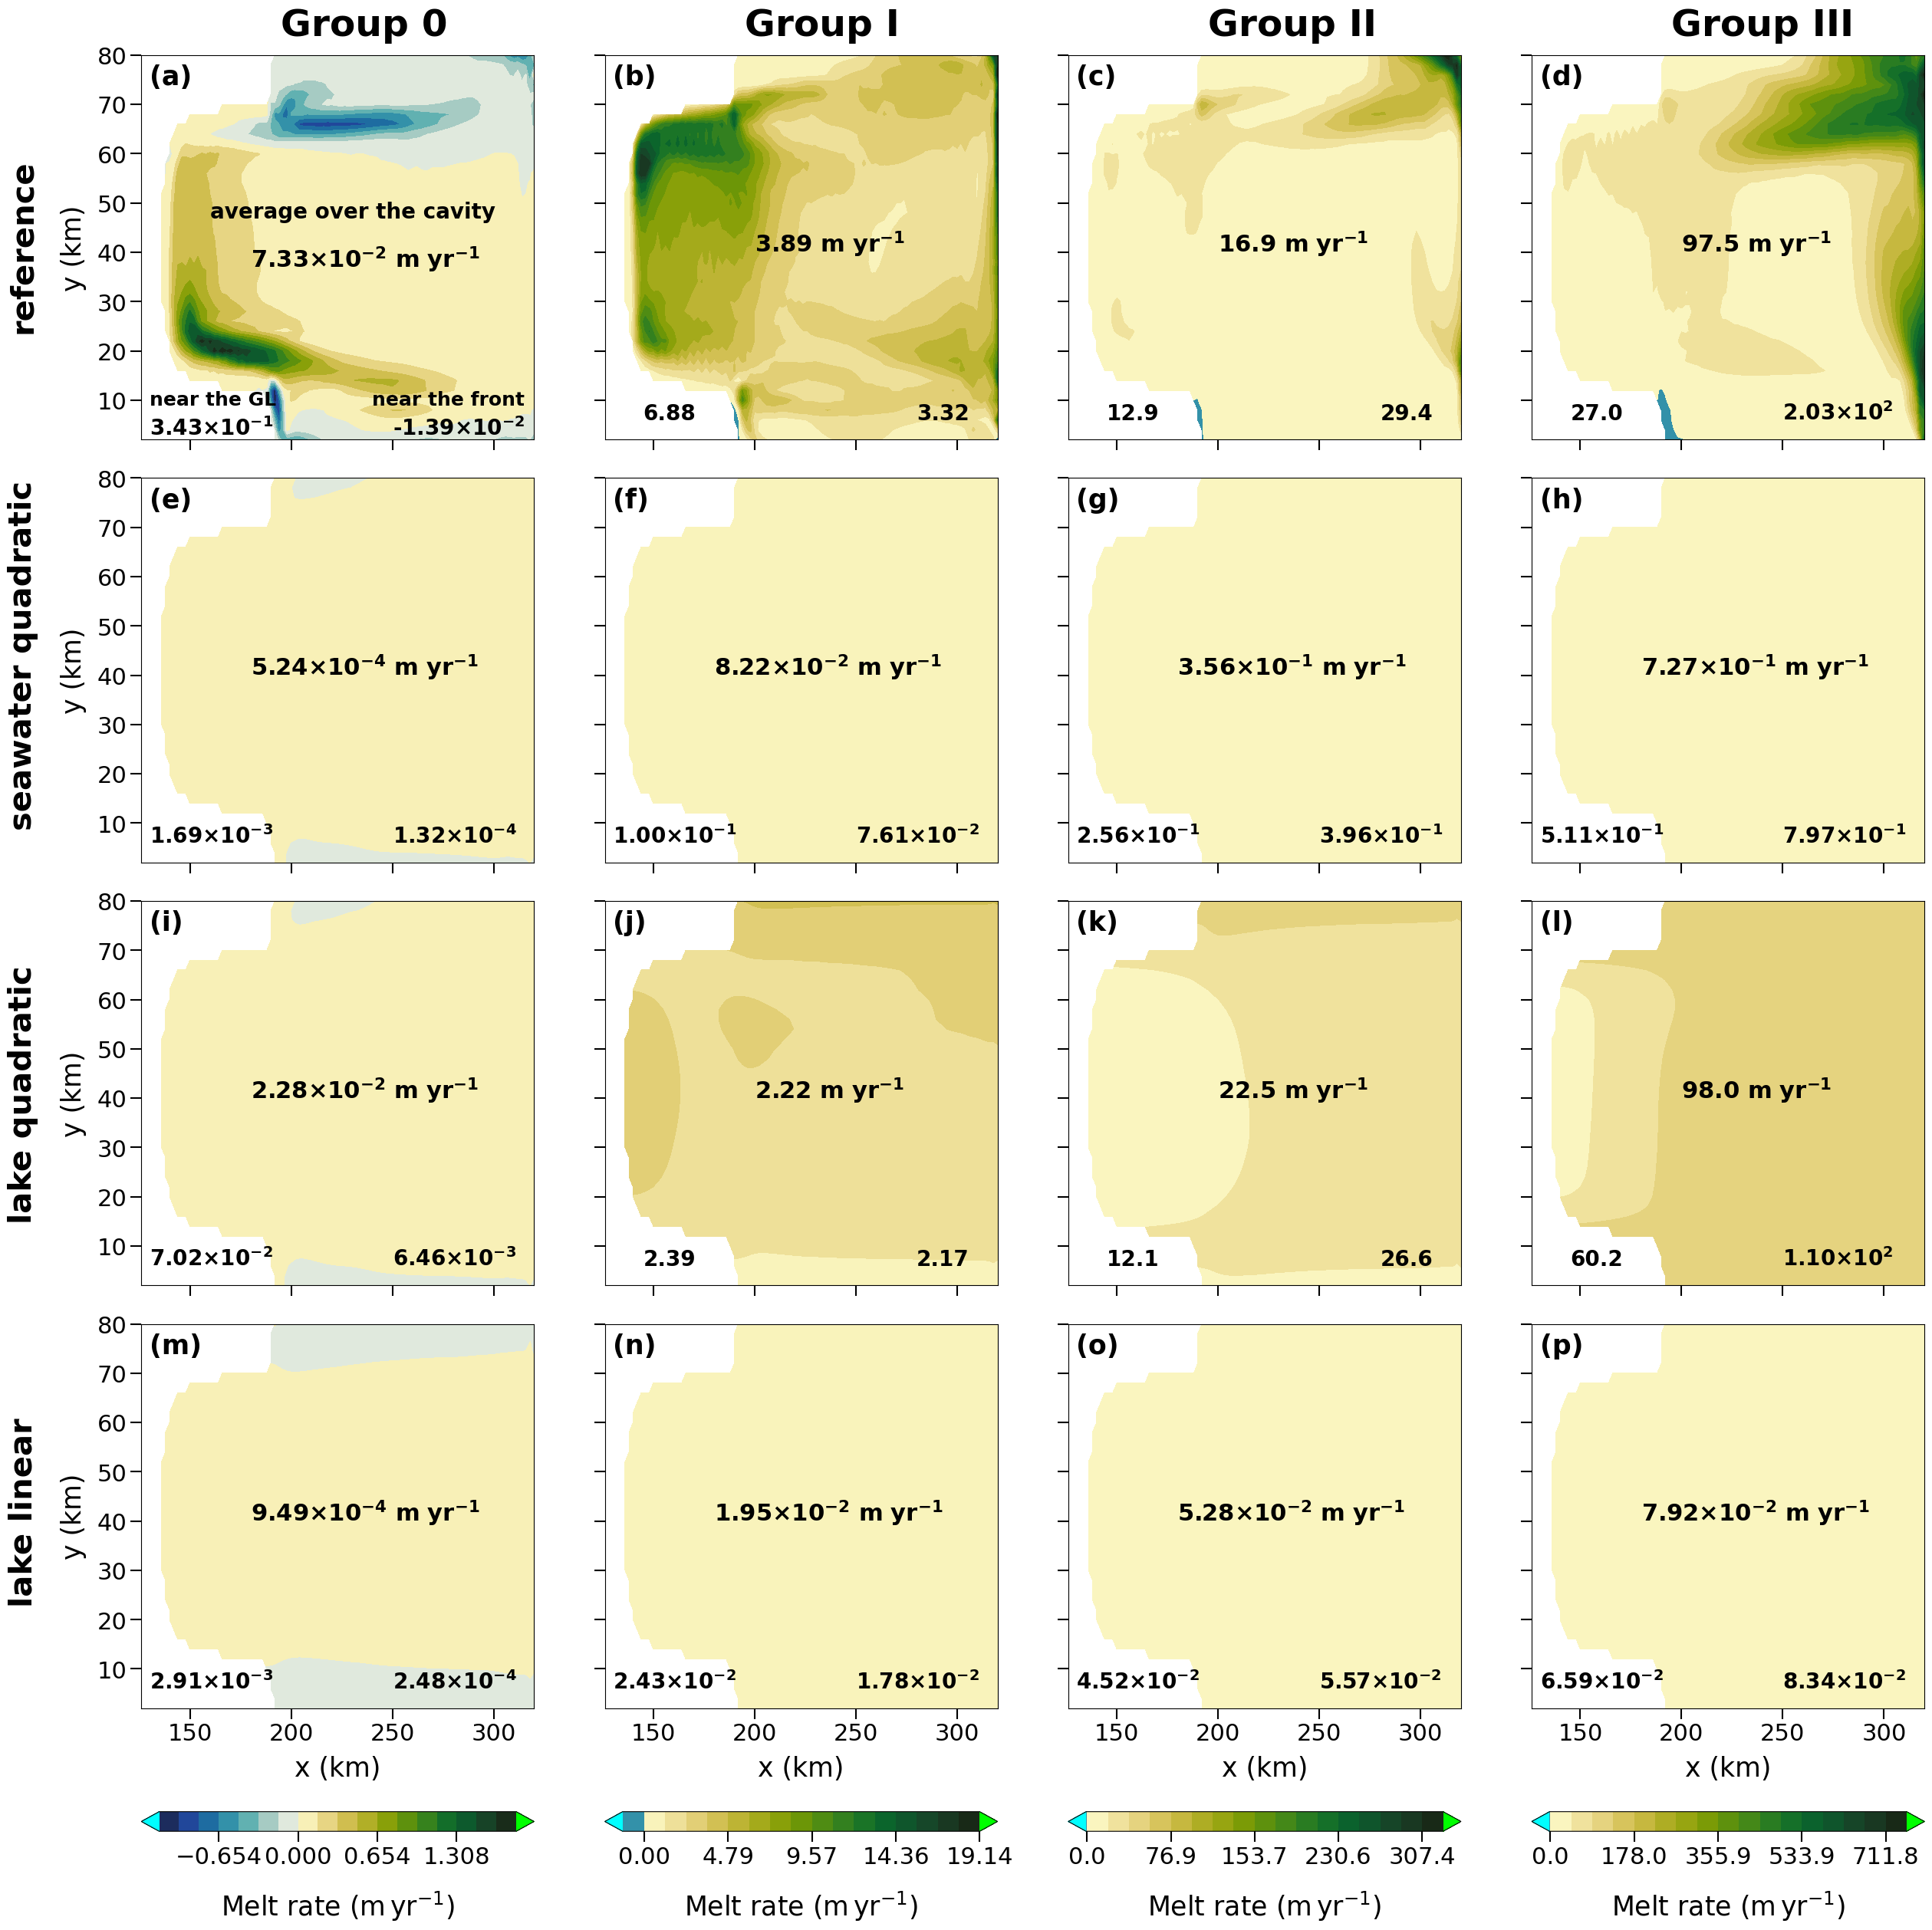

In [58]:
#create the figure
fig_fonte,((ax11,ax12,ax13,ax14),(ax21,ax22,ax23,ax24),(ax31,ax32,ax33,ax34),(ax41,ax42,ax43,ax44))=plt.subplots(4,4,figsize=(30,35),sharex=True,sharey=True)
fig_fonte.subplots_adjust(wspace=0.18,hspace=0.1)

axes=[(ax11,ax12,ax13,ax14),(ax21,ax22,ax23,ax24),(ax31,ax32,ax33,ax34),(ax41,ax42,ax43,ax44)]

#some labels
labelsubfig=[("(a)","(b)","(c)","(d)"),("(e)","(f)","(g)","(h)"),("(i)","(j)","(k)","(l)"),("(m)","(n)","(o)","(p)")]

#set up the color of the maps
cmap=cmo.delta ; cmap.set_under("cyan") ; cmap.set_over("lime")

#coef to convert into m/year
coef_conv=conv_invs_invan/rhofw

#iterate over the groups
for lf in range(4):
    
    #same levels for a given group based on the reference (NEMO's outputs)
    val_minf_globale=(fonte_yrmoy_groups[lf]*masque_interet).min(axis=(0,1))*coef_conv
    val_maxf_globale=(fonte_yrmoy_groups[lf]*masque_interet).max(axis=(0,1))*coef_conv
    
    norm=mcolors.TwoSlopeNorm(vcenter=0)
    
    if lf==0:
        levels=np.arange(val_minf_globale,val_maxf_globale+np.abs(val_minf_globale)/7,np.abs(val_minf_globale)/7)
    elif lf==1:
        levels=np.concatenate((np.array([val_minf_globale]),np.linspace(0.0,val_maxf_globale,17)))
    else:
        levels=np.concatenate((np.array([val_minf_globale]),np.linspace(0.0,val_maxf_globale,18)))
    print(levels)
    
    #reference melt (NEMO's outputs)
    
    cff0=axes[0][lf].contourf(fonte_yrmoy_groups[lf].x[xpos_gl-5:xpos_frontsp+1]*2,fonte_yrmoy_groups[lf].y[1:-1]*2,(fonte_yrmoy_groups[lf][1:-1,xpos_gl-5:xpos_frontsp+1]*coef_conv).where(masque_interet[1:-1,xpos_gl-5:xpos_frontsp+1]>0),levels=levels,cmap=cmap,norm = norm,extend="both")
   
        #set up the axes
    axes[0][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    
        #set up some labels
    axes[0][lf].text(130,74,labelsubfig[0][lf],fontsize=25,fontweight="bold")
       
        #plot some values
       
            ##mean over the cavity
    if int(f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[0][lf].text(200,40-3*(lf==0),f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0]+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    elif int(f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[0][lf].text(200,40-3*(lf==0),str(np.round(float(f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1))+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    else:
        axes[0][lf].text(180,40-3*(lf==0),f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_cavite_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$"+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)
            
            ##mean near the grounding line
    if int(f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[0][lf].text(145,6-3*(lf==0),f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[0][lf].text(145,6-3*(lf==0),str(np.round(float(f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[0][lf].text(130,6-3*(lf==0),f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_GL_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
            
            ##mean near the front
    if int(f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        
        axes[0][lf].text(280,6-3*(lf==0),f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[0][lf].text(280,6-3*(lf==0),str(np.round(float(f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[0][lf].text(250,6-3*(lf==0),f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_front_param_ref_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
    
    #melt param CB
    
    cff1=axes[1][lf].contourf(fonte_param_CB_groups[lf].x[xpos_gl-5:xpos_frontsp+1]*2,fonte_param_CB_groups[lf].y[1:-1]*2,(fonte_param_CB_groups[lf][1:-1,xpos_gl-5:xpos_frontsp+1]*coef_conv).where(masque_interet[1:-1,xpos_gl-5:xpos_frontsp+1]>0),levels=levels,cmap=cmap,norm = norm,extend="both")

        #set up the axes
    axes[1][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    
        #set up some labels
    axes[1][lf].text(130,74,labelsubfig[1][lf],fontsize=25,fontweight="bold")
       
        #plot some values
       
            ##mean over the cavity
    if int(f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[1][lf].text(200,40,f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0]+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    elif int(f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[1][lf].text(200,40,str(np.round(float(f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1))+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    else:
        axes[1][lf].text(180,40,f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_cavite_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$"+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)
            
            ##mean near the grounding line
    if int(f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[1][lf].text(145,6,f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[1][lf].text(145,6,str(np.round(float(f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[1][lf].text(130,6,f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_GL_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
            
            ##mean near the front
    if int(f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[1][lf].text(280,6,f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[1][lf].text(280,6,str(np.round(float(f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[1][lf].text(250,6,f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_front_param_CB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
       
    #melt new param
    
    cff2=axes[2][lf].contourf(fonte_param_revisiteCB_groups[lf].x[xpos_gl-5:xpos_frontsp+1]*2,fonte_param_revisiteCB_groups[lf].y[1:-1]*2,(fonte_param_revisiteCB_groups[lf][1:-1,xpos_gl-5:xpos_frontsp+1]*coef_conv).where(masque_interet[1:-1,xpos_gl-5:xpos_frontsp+1]>0),levels=levels,cmap=cmap,norm = norm,extend="both")
       
        #set up the axes
    axes[2][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    
        #set up some labels
    axes[2][lf].text(130,74,labelsubfig[2][lf],fontsize=25,fontweight="bold")
       
        #plot some values
       
            ##mean over the cavity
    if int(f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[2][lf].text(200,40,f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0]+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    elif int(f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[2][lf].text(200,40,str(np.round(float(f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1))+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    else:
        axes[2][lf].text(180,40,f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_cavite_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$"+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)
            
            ##mean near the grounding line
    if int(f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[2][lf].text(145,6,f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[2][lf].text(145,6,str(np.round(float(f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[2][lf].text(130,6,f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_GL_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
            
            ##mean near the front
    if int(f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[2][lf].text(280,6,f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[2][lf].text(280,6,str(np.round(float(f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[2][lf].text(250,6,f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_front_param_revisiteCB_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
        
    #melt linear lake param
    
    cff3=axes[3][lf].contourf(fonte_param_linfw_groups[lf].x[xpos_gl-5:xpos_frontsp+1]*2,fonte_param_linfw_groups[lf].y[1:-1]*2,(fonte_param_linfw_groups[lf][1:-1,xpos_gl-5:xpos_frontsp+1]*coef_conv).where(masque_interet[1:-1,xpos_gl-5:xpos_frontsp+1]>0),levels=levels,cmap=cmap,norm = norm,extend="both")
  
        #set up the axes
    axes[3][lf].tick_params(axis="both",labelsize=22,size=10,width=1.5)
    axes[3][lf].set_xlabel("x (km)",fontsize=25,labelpad=10)
    
        #set up some labels
    axes[3][lf].text(130,74,labelsubfig[3][lf],fontsize=25,fontweight="bold")
    
        #plot some values
            
            ##mean over the cavity
        
    if int(f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[3][lf].text(200,40,f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0]+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    elif int(f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[3][lf].text(200,40,str(np.round(float(f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1))+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)

    else:
        axes[3][lf].text(180,40,f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_cavite_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$"+" "+r"$\mathrm{\mathbf{m \ yr^{-1}}}$",fontweight="bold",fontsize=22)
            
            ##mean near the grounding line
    
    if int(f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[3][lf].text(145,6,f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[3][lf].text(145,6,str(np.round(float(f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[3][lf].text(130,6,f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_GL_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
            
            ##mean near the front
            
    if int(f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) == 0:
        axes[3][lf].text(280,6,f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0],fontweight="bold",fontsize=20)

    elif int(f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]) ==1:
        axes[3][lf].text(280,6,str(np.round(float(f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0])*10,1)),fontweight="bold",fontsize=20)

    else:
        axes[3][lf].text(250,6,f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[0]+r"$ \mathrm{\mathbf{\times 10^{"+str(int(f"{(fonte_front_param_linfw_groups[lf].values*coef_conv):.2e}".split("e")[1]))+"}}}$",fontweight="bold",fontsize=20)
        
        #set up the colorbar
    if lf==0:
        cbar=fig_fonte.colorbar(cff3,ax=(axes[0][lf],axes[1][lf],axes[2][lf],axes[3][lf]),ticks=levels[3::4],location="bottom",pad=0.05,spacing="proportional",extend="both")
    else:
        cbar=fig_fonte.colorbar(cff3,ax=(axes[0][lf],axes[1][lf],axes[2][lf],axes[3][lf]),ticks=levels[1::4],location="bottom",pad=0.05,spacing="proportional",extend="both")
    cbar.ax.tick_params(labelsize=22,size=10,width=1.5)
    cbar.set_label(label="Melt rate ("+r"$\mathrm{m\,yr^{-1}}$"+")",size=25,labelpad=20)

#set up legend of the displayed numbers
axes[0][0].text(160,50-3,"average over the cavity",fontsize=20,fontweight="bold")
axes[0][0].text(130,14-5,"near the GL",fontsize=18,fontweight="bold")
axes[0][0].text(240,14-5,"near the front",fontsize=18,fontweight="bold")
    
#set up the axes
axes[0][0].set_ylabel("y (km)",fontsize=25,labelpad=10)
axes[1][0].set_ylabel("y (km)",fontsize=25,labelpad=10)
axes[2][0].set_ylabel("y (km)",fontsize=25,labelpad=10)
axes[3][0].set_ylabel("y (km)",fontsize=25,labelpad=10)

#set up some legends
axes[0][0].text(195,84,"Group 0",fontsize=35,fontweight="bold")
axes[0][1].text(195,84,"Group I",fontsize=35,fontweight="bold")
axes[0][2].text(195,84,"Group II",fontsize=35,fontweight="bold")
axes[0][3].text(195,84,"Group III",fontsize=35,fontweight="bold")
axes[0][0].text(60,25,"reference",fontsize=30,fontweight="bold",rotation="vertical")
axes[1][0].text(60,10,"seawater quadratic",fontsize=30,fontweight="bold",rotation="vertical")
axes[2][0].text(60,16,"lake quadratic",fontsize=30,fontweight="bold",rotation="vertical")
axes[3][0].text(60,24,"lake linear",fontsize=30,fontweight="bold",rotation="vertical")

plt.show()
#save the figure
#fig_fonte.savefig("taux_fonte_param.png",facecolor="white",edgecolor="none",bbox_inches='tight',dpi=300)

## Some computations considering only experiments with salinity of 0.001 g/kg

In [59]:
#experiments with only salinity of 0.001 g/kg
for lfs in range(nbre_temp_diff):
    print(nom_experiences[lfs])

S0_001_T0_1
S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_001_T6
S0_001_T6-4
S0_001_T8
S0_001_T8-4
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8


In [60]:
#mean melt rates for each group considering only experiments with a salinity of 0.001 g/kg

fonte_param_CB_0_001_groups=[fonte_param_CB[0],0.0,0.0,0.0] #Clara Burgard's formulation
fonte_param_revisiteCB_0_001_groups=[fonte_param_revisiteCB[0],0.0,0.0,0.0] #new formulation
fonte_param_linfw_0_001_groups=[fonte_param_linfw[0],0.0,0.0,0.0] #linear lake formulation

#number of experiments per group considering only experiments with a salinity of 0.001 g/kg

nbreGI_0_001=np.sum(np.array([GroupI_manu])<nbre_temp_diff)
print("nbreGI_0_001",nbreGI_0_001)
nbreGII_0_001=np.sum(np.array([GroupII_manu])<nbre_temp_diff)
print("nbreGII_0_001",nbreGII_0_001)
nbreGIII_0_001=np.sum(np.array([GroupIII_manu])<nbre_temp_diff)
print("nbreGIII_0_001",nbreGIII_0_001)

#compute the means
for lfs in range(1,nbre_temp_diff):
    print(nom_experiences[lfs])
    
    if lfs in GroupI_manu:
        print("GroupI")
        
        ##moyenne fonte
        fonte_param_CB_0_001_groups[1]+=fonte_param_CB[lfs]/nbreGI_0_001
        fonte_param_revisiteCB_0_001_groups[1]+=fonte_param_revisiteCB[lfs]/nbreGI_0_001
        fonte_param_linfw_0_001_groups[1]+=fonte_param_linfw[lfs]/nbreGI_0_001
        
    elif lfs in GroupII_manu:
        print("GroupII")
        
        ##moyenne fonte
        fonte_param_CB_0_001_groups[2]+=fonte_param_CB[lfs]/nbreGII_0_001
        fonte_param_revisiteCB_0_001_groups[2]+=fonte_param_revisiteCB[lfs]/nbreGII_0_001
        fonte_param_linfw_0_001_groups[2]+=fonte_param_linfw[lfs]/nbreGII_0_001
               
    elif lfs in GroupIII_manu:
        print("GroupIII")
        
        ##moyenne fonte
        fonte_param_CB_0_001_groups[3]+=fonte_param_CB[lfs]/nbreGIII_0_001
        fonte_param_revisiteCB_0_001_groups[3]+=fonte_param_revisiteCB[lfs]/nbreGIII_0_001
        fonte_param_linfw_0_001_groups[3]+=fonte_param_linfw[lfs]/nbreGIII_0_001
            
    else:
        print("problem")

nbreGI_0_001 4
nbreGII_0_001 3
nbreGIII_0_001 5
S0_001_T1
GroupI
S0_001_T1-2
GroupI
S0_001_T1-3
GroupI
S0_001_T3
GroupI
S0_001_T6
GroupII
S0_001_T6-4
GroupII
S0_001_T8
GroupIII
S0_001_T8-4
GroupII
S0_001_T8-6
GroupIII
S0_001_T10
GroupIII
S0_001_T10-6
GroupIII
S0_001_T10-8
GroupIII


In [61]:
#mean melt rates over the cavity, close to the grounding line, close to the front
#for each group considering only experiments with a salinity of 0.001 g/kg

    #over cavity
fonte_cavite_param_CB_0_001_groups=[] ; fonte_cavite_param_revisiteCB_0_001_groups=[]
fonte_cavite_param_linfw_0_001_groups=[]

    #close to the grounding line
fonte_GL_param_CB_0_001_groups=[] ; fonte_GL_param_revisiteCB_0_001_groups=[]
fonte_GL_param_linfw_0_001_groups=[]

    #close to the front
fonte_front_param_CB_0_001_groups=[] ; fonte_front_param_revisiteCB_0_001_groups=[]
fonte_front_param_linfw_0_001_groups=[]

for lg in range(4):
    #over cavity
    fonte_cavite_param_CB_0_001_groups.append(fonte_param_CB_0_001_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
    fonte_cavite_param_revisiteCB_0_001_groups.append(fonte_param_revisiteCB_0_001_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
    fonte_cavite_param_linfw_0_001_groups.append(fonte_param_linfw_0_001_groups[lg].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))

    #close to the grounding line
    fonte_GL_param_CB_0_001_groups.append(fonte_param_CB_0_001_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
    fonte_GL_param_revisiteCB_0_001_groups.append(fonte_param_revisiteCB_0_001_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
    fonte_GL_param_linfw_0_001_groups.append(fonte_param_linfw_0_001_groups[lg].fillna(0)[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1))/masque_interet[:,xpos_gl:xpos_gl+nbre_km//2+1].sum(axis=(0,1)))
    
    #close to the front
    fonte_front_param_CB_0_001_groups.append(fonte_param_CB_0_001_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))
    fonte_front_param_revisiteCB_0_001_groups.append(fonte_param_revisiteCB_0_001_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))
    fonte_front_param_linfw_0_001_groups.append(fonte_param_linfw_0_001_groups[lg].fillna(0)[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1))/masque_interet[:,xpos_frontsp-nbre_km//2:xpos_frontsp+1].sum(axis=(0,1)))

In [62]:
#convert into m/year
print(np.array(fonte_cavite_param_CB_0_001_groups)*conv_invs_invan/rhofw)
print(np.array(fonte_cavite_param_revisiteCB_0_001_groups)*conv_invs_invan/rhofw)
print(np.array(fonte_cavite_param_linfw_0_001_groups)*conv_invs_invan/rhofw)

[8.9199284e-07 7.0221940e-05 6.6434365e-04 1.6591587e-03]
[1.9000778e-02 4.7036502e-01 1.8326218e+01 9.6419601e+01]
[0.00078382 0.01399702 0.04967234 0.07870457]


In [63]:
#mean melt rates over the cavity for the reference (NEMO's outputs)
#for each group considering only experiments with a salinity of 0.001 g/kg

fonte_cavite_ref_0_001_groups=[]
fonte_cavite_ref_0_001_groups_temp=[0.0,0.0,0.0,0.0]

for lfs in range(1,nbre_temp_diff):
    print(nom_experiences[lfs])
    
    if lfs in GroupI_manu:
        fonte_cavite_ref_0_001_groups_temp[1]+=(fonte_yrmoy[lfs]*masque_interet)/nbreGI_0_001
    elif lfs in GroupII_manu:
        fonte_cavite_ref_0_001_groups_temp[2]+=(fonte_yrmoy[lfs]*masque_interet)/nbreGII_0_001
    elif lfs in GroupIII_manu:
        fonte_cavite_ref_0_001_groups_temp[3]+=(fonte_yrmoy[lfs]*masque_interet)/nbreGIII_0_001
        
fonte_cavite_ref_0_001_groups.append((fonte_yrmoy[0]*masque_interet).fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
fonte_cavite_ref_0_001_groups.append(fonte_cavite_ref_0_001_groups_temp[1].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
fonte_cavite_ref_0_001_groups.append(fonte_cavite_ref_0_001_groups_temp[2].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))
fonte_cavite_ref_0_001_groups.append(fonte_cavite_ref_0_001_groups_temp[3].fillna(0).sum(axis=(0,1))/masque_interet.sum(axis=(0,1)))

S0_001_T1
S0_001_T1-2
S0_001_T1-3
S0_001_T3
S0_001_T6
S0_001_T6-4
S0_001_T8
S0_001_T8-4
S0_001_T8-6
S0_001_T10
S0_001_T10-6
S0_001_T10-8


In [64]:
#convert into m/year
print(np.array([fonte_cavite_ref_0_001_groups]))
print(np.array([fonte_cavite_ref_0_001_groups])*conv_invs_invan/rhofw)

[[1.83657180e-06 8.96641829e-05 4.79459177e-04 3.24141835e-03]]
[[5.79181283e-02 2.82764967e+00 1.51202246e+01 1.02221369e+02]]
